In [1]:
import numpy as np
import pandas as pd
import seaborn as sea 
import matplotlib.pyplot as plt
import phik

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import average_precision_score
from sklearn.base import clone

import lightgbm, xgboost, catboost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression


import optuna
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

---
# 1. Setting up Utility Functions

In [2]:
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    X_copy = X.copy()
    X_copy["txn_count_last_24h"] = X_copy["txn_count_last_24h"].clip(upper=9)
    return X_copy


def convert_cat_features(X:pd.DataFrame, cat_features:list) -> pd.DataFrame:
    X_copy = X.copy()
    X_copy[cat_features] = X_copy[cat_features].astype("category")
    return X_copy


def process_features(X:pd.DataFrame, cat_features:list) -> pd.DataFrame:
    X_copy = engineer_features(X)
    X_copy = convert_cat_features(X_copy, cat_features)
    return X_copy

In [3]:
def make_train_test_sets(path:str, target_variable="is_fraud", test_size=0.3, random_state=3126):
    """
    Parameters:
        path (str): Path to the CSV file containing the dataset.
        target_variable (str): Name of the target column to predict. Default "is_fraud".
        test_size (float): Proportion of data to allocate to the test set. Default 0.3.
        random_state (int): Seed for reproducible splitting. Default 3126.
    Return:
        X_train, X_test, y_train, y_test: Stratified train/test split of features and target.
    """
    ## Reads data and splits into X and y 
    X  = pd.read_csv(path).drop(columns=["transaction_id"])
    y  = X.pop(target_variable)
    
    ## Splits intro train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=random_state, shuffle=True, stratify=y
    )
    ## Reset indices after splitting
    X_train = X_train.reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test  = y_test.reset_index(drop=True)
    
    return X_train, X_test, y_train, y_test

In [4]:
def cross_validate(model, model_name, X, y, cat_features, save_model_path, scorer=average_precision_score, n_splits=5, random_state=3126):
    """
    Params:
        model: unfitted sklearn-compatible estimator to clone and fit each fold.
        model_name: one of "lgbm", "xgb", "catboost", or other (plain .fit()).
        X: feature matrix.
        y: target vector, index-aligned with X.
        save_model_path: directory to dump fold models to; skipped if None.
        scorer: metric function scorer(y_true, y_pred) -> float.
        n_splits: number of StratifiedKFold splits. Default 5.
        random_state: seed for fold shuffling. Default 3126.

    Return:
        dict: {
            "scores": array of per-fold metric values,
            "OOF": out-of-fold predictions,
            "fold_number": fold id per sample
        }
    """

    skf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=True)
    history = {
        "scores": np.zeros(n_splits),
        "OOF": np.zeros(len(y)),
        "fold_number": np.zeros(len(y))
    }

    for k,(train_idx,val_idx) in enumerate(skf.split(X, y)):
        X_t, y_t = X.iloc[train_idx,:], y[train_idx]
        X_v, y_v = X.iloc[val_idx,:],   y[val_idx]

        ## Process features
        X_t = process_features(X_t, cat_features)
        X_v = process_features(X_v, cat_features)
        
        # Fits appropriate cloned model
        if model_name == "catboost":
            cloned_model = CatBoostClassifier(**model.get_params())
        else:
            cloned_model = clone(model)

        
        if model_name == "lgbm":
            cloned_model.fit(X_t, y_t)
            
        elif model_name == "xgb":
            cloned_model.fit(X_t, y_t, verbose=False)

        elif model_name == "catboost":
            cloned_model.fit(X_t, y_t, cat_features=cat_features, verbose=False)

        else: cloned_model.fit(X_t, y_t)

        # Make predictions and store results
        y_preds = cloned_model.predict_proba(X_v)[:, -1]
        
        history["OOF"][val_idx] = y_preds
        history["fold_number"][val_idx] = k + 1
        history["scores"][k] = scorer(y_v, y_preds)

        # Saves model if needed
        if save_model_path is not None:
            joblib.dump(cloned_model, f"{save_model_path}/{model_name}_{k + 1}.joblib")
    return history

In [5]:
def test_model(model, model_name, X_test, y_test, scorer=average_precision_score):
    """
    Evaluate a trained classifier on a test set using probability-based scoring
    and print the result.

    Params:
        model (estimator): Trained classifier with a `predict_proba` method.
        model_name (str): Name of the model, used for the printed output.
        X_test: Test set features.
        y_test: True labels for the test set.
        scorer (callable): Scoring function with signature `scorer(y_true, y_score)`

    Return:
        None. Prints the computed score.
    """
    y_preds = model.predict_proba(X_test)
    score   = scorer(y_test, y_preds)
    print(f"Average Precision of {model_name} on Test Set: {score:.3f}")

--- 
# 2. Setting up Constants and Hyper-parameters

In [6]:
SEED = 3126

CAT_FEATURES = [
    'merchant_category','card_type', 'auth_method',
    'channel', 'device_type', 'day_of_week'
]


LGBM_PARAMS = {
    'max_depth': 2,
    'learning_rate': 0.07461718009719123,
    'min_child_samples': 108,
    'colsample_bytree': 0.5369984053520471,
    'subsample_freq': 4,
    'subsample': 0.7511542308555871,
    'reg_alpha': 0.013074071755364779,
    'reg_lambda': 0.0008606603803609922,
    'scale_pos_weight': 1.1103974516053718,
    'num_leaves': 4,
    ## Constants
    'n_estimators':130,
    'random_state':SEED,
    'metric':'average_precision',
    'verbose':-1,
    'n_jobs':-1
}


XGB_PARAMS = {
    'learning_rate': 0.09337094415803539,
    'colsample_bytree': 0.6475628016664312,
    'subsample': 0.6975963364412459,
    'reg_alpha': 1.1303419470280986e-05,
    'reg_lambda': 0.0059375831020790195,
    'gamma': 0.0009892073499964695,
    'min_child_weight': 3.5939245218014833,
    'grow_policy': 'lossguide',
    'scale_pos_weight': 2.3635951892927065,
    'max_leaves': 4,
    ## Constants
    'n_estimators':112,
    'enable_categorical':True,
    'eval_metric':"aucpr",
    'random_state':SEED,
    'verbosity':0,
    'n_jobs':-1
}


CAT_PARAMS = {
    'learning_rate': 0.11422046426502673, 
    'l2_leaf_reg': 2.931964012979458, 
    'depth': 2, 
    'random_strength': 0.650825384661738, 
    'bootstrap_type': 'Bernoulli', 
    'subsample': 0.5998462283815383, 
    'rsm': 0.8092477080727568, 
    'min_data_in_leaf': 25,
    'class_weights': [1.0, 3.513505010540427],
    ## Constants
    'n_estimators':142,
    'random_state':SEED,
    'eval_metric':"PRAUC",
    'thread_count':-1
}

---
# 3. Optuna Optimization

In [7]:
file_path = "/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv"
X_train, X_test, y_train, y_test = make_train_test_sets(file_path)

In [8]:
lgbm_mod = LGBMClassifier(**LGBM_PARAMS)
xgb_mod  = XGBClassifier(**XGB_PARAMS)
cat_mod  = CatBoostClassifier(**CAT_PARAMS)

hist_lgbm = cross_validate(lgbm_mod, "lgbm", X_train, y_train, CAT_FEATURES, None)
hist_xgb  = cross_validate(xgb_mod, "xgb", X_train, y_train, CAT_FEATURES, None)
hist_cat  = cross_validate(cat_mod, "catboost", X_train, y_train, CAT_FEATURES, None)

oof_lgbm = hist_lgbm["OOF"]
oof_xgb  = hist_xgb["OOF"]
oof_cat  = hist_cat["OOF"]

In [9]:
print(f"LGBMClassifier OOF AP Score: {average_precision_score(y_train, oof_lgbm):.3f}")
print(f"XGBClassifier OOF AP Score: {average_precision_score(y_train, oof_xgb):.3f}")
print(f"CatBoostClassifier OOF AP Score: {average_precision_score(y_train, oof_cat):.3f}")

LGBMClassifier OOF AP Score: 0.420
XGBClassifier OOF AP Score: 0.402
CatBoostClassifier OOF AP Score: 0.421


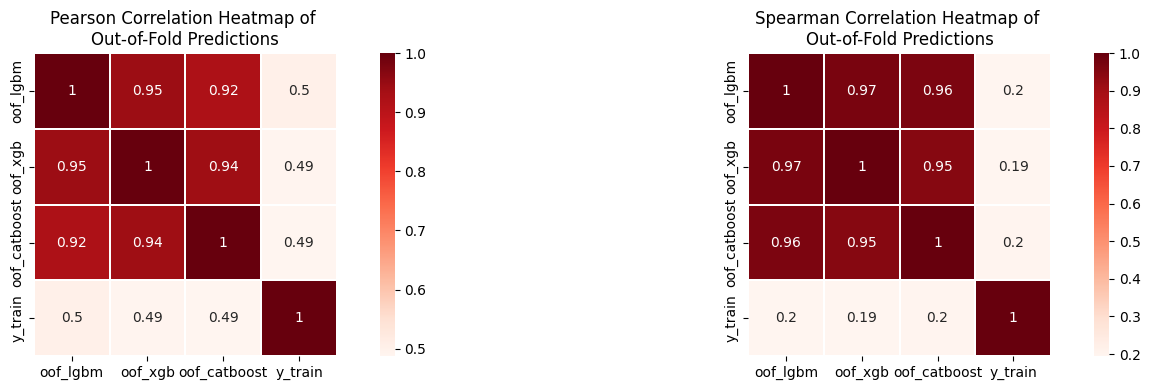

In [10]:
oof_result = pd.DataFrame({
    "oof_lgbm":oof_lgbm,
    "oof_xgb":oof_xgb,
    "oof_catboost":oof_cat,
    "y_train":y_train
})

plt.figure(figsize=(16,4))
plt.subplot(121)
corr_matrix = oof_result.corr(method="pearson")
sea.heatmap(corr_matrix, annot=corr_matrix, cmap="Reds", linewidths=.1, square=True)
plt.title("Pearson Correlation Heatmap of \nOut-of-Fold Predictions")

plt.subplot(122)
corr_matrix = oof_result.corr(method="spearman")
sea.heatmap(corr_matrix, annot=corr_matrix, cmap="Reds", linewidths=.1, square=True)
plt.title("Spearman Correlation Heatmap of \nOut-of-Fold Predictions")

plt.tight_layout()
plt.show()

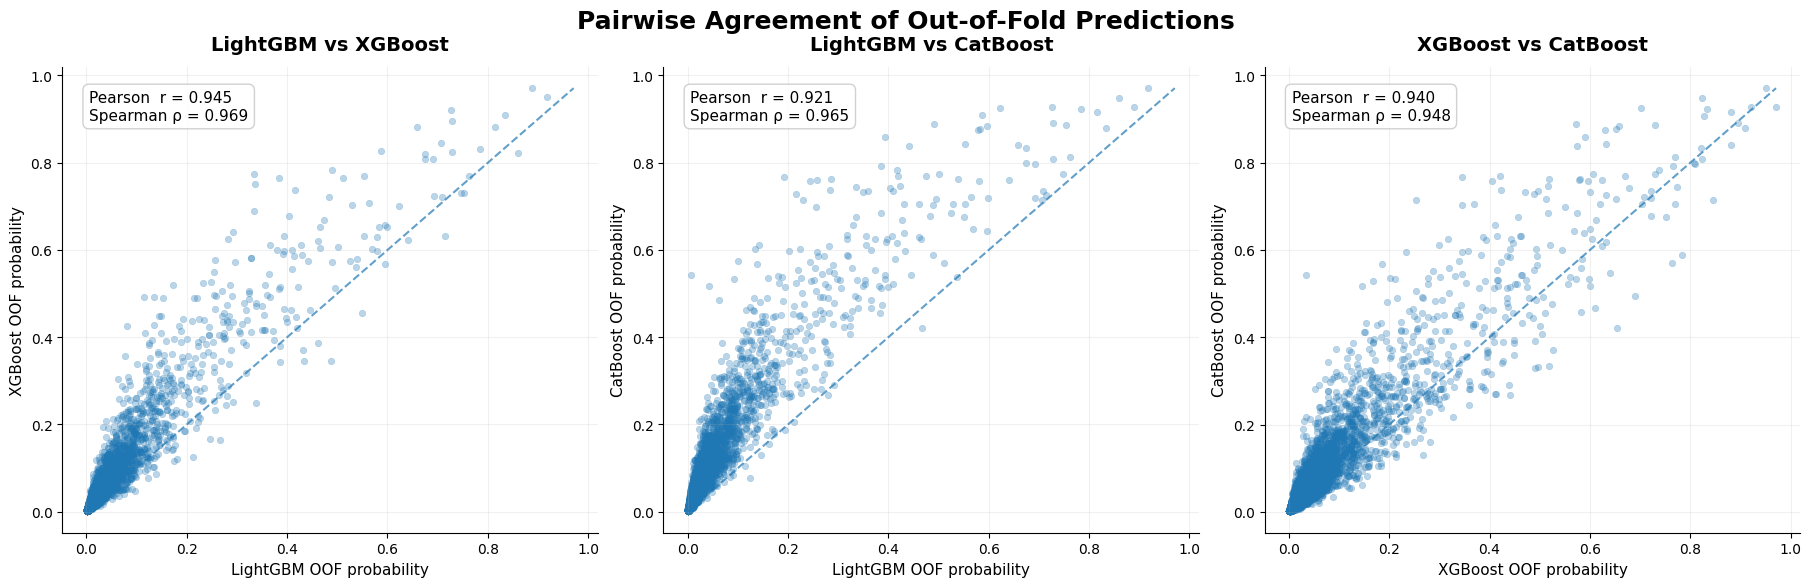

In [11]:
from scipy.stats import pearsonr, spearmanr

pairs = [
    ("oof_lgbm", "oof_xgb", "LightGBM", "XGBoost"),
    ("oof_lgbm", "oof_catboost", "LightGBM", "CatBoost"),
    ("oof_xgb", "oof_catboost", "XGBoost", "CatBoost"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

for ax, (x_col, y_col, x_name, y_name) in zip(axes, pairs):
    x = oof_result[x_col]
    y = oof_result[y_col]

    pearson  = pearsonr(x, y)[0]
    spearman = spearmanr(x, y)[0]

    # Scatter
    sea.scatterplot(x=x, y=y, ax=ax, s=22, alpha=0.30, edgecolor=None)

    # Perfect-agreement line
    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        label="Perfect agreement"
    )

    # Correlation annotation
    ax.text(
        0.05, 0.95,
        f"Pearson  r = {pearson:.3f}\n"
        f"Spearman ρ = {spearman:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="0.8",
            alpha=0.9
        )
    )

    ax.set_title(
        f"{x_name} vs {y_name}",
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel(f"{x_name} OOF probability", fontsize=11)
    ax.set_ylabel(f"{y_name} OOF probability", fontsize=11)

    ax.grid(True, alpha=0.18, linewidth=0.8)
    sea.despine(ax=ax)

fig.suptitle("Pairwise Agreement of Out-of-Fold Predictions", fontsize=18, fontweight="bold", y=1.04)
plt.show()

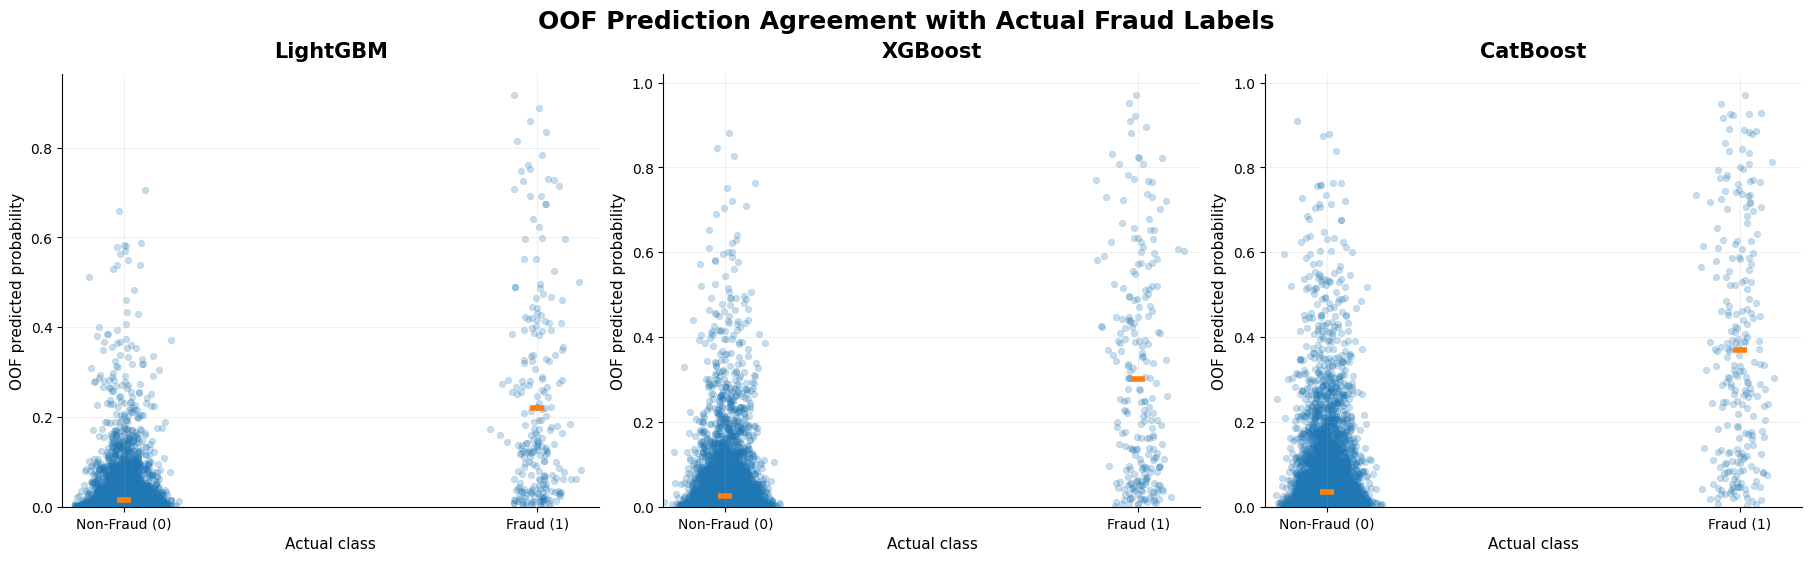

In [12]:
models = [
    ("oof_lgbm", "LightGBM"),
    ("oof_xgb", "XGBoost"),
    ("oof_catboost", "CatBoost")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
rng = np.random.default_rng(SEED)

for ax, (col, name) in zip(axes, models):

    y_pred = oof_result[col]
    y_true = oof_result["y_train"]

    # Small jitter so individual observations are visible
    x_jitter = y_true + rng.normal(0, 0.035, size=len(y_true))

    sea.scatterplot(x=x_jitter, y=y_pred, ax=ax, s=22, alpha=0.25, edgecolor=None)

    # Mean predicted probability for each class
    means = y_pred.groupby(y_true).mean()

    ax.scatter([0, 1], [means.loc[0], means.loc[1]], s=100, marker="_", linewidths=4, zorder=5)

    ax.set_title(f"{name}", fontsize=15, fontweight="bold", pad=12)
    ax.set_xlabel("Actual class", fontsize=11)
    ax.set_ylabel("OOF predicted probability", fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-Fraud (0)", "Fraud (1)"])
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.18, linewidth=0.8)

    sea.despine(ax=ax)
fig.suptitle("OOF Prediction Agreement with Actual Fraud Labels", fontsize=18, fontweight="bold")

plt.show()

# 3.1 Optimizing Classifiers' Weights

In [13]:
# def objective(trial):
#     weights = np.array([
#         trial.suggest_float("lgbm_w", 0.0, 1.0),
#         trial.suggest_float("xgb_w",  0.0, 1.0),
#         trial.suggest_float("cat_w",  0.0, 1.0)
#     ])
#     weights /= weights.sum()
    
#     ensemble_pred = (
#         weights[0] * oof_lgbm +
#         weights[1] * oof_xgb +
#         weights[1] * oof_cat
#     )
#     return average_precision_score(y_train, ensemble_pred)


# study = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(seed=SEED)
# )
# study.optimize(objective, n_trials=1000)  

In [14]:
class TreeEnsemble():
    def __init__(self, weights, cat_features=CAT_FEATURES, 
                 lgbm_params:dict=LGBM_PARAMS, xgb_params:dict=XGB_PARAMS, cat_params:dict=CAT_PARAMS):
        self.weights = np.asarray(weights)
        self.cat_features = cat_features
        self.lgbm_params  = lgbm_params
        self.xgb_params   = xgb_params
        self.cat_params   = cat_params
        self.lgbm_mod = LGBMClassifier(**lgbm_params)
        self.xgb_mod  = XGBClassifier(**xgb_params)
        self.cat_mod  = CatBoostClassifier(**cat_params)
        
    def fit(self, X, y):
        self.lgbm_mod.fit(X, y)
        self.xgb_mod.fit(X, y)
        self.cat_mod.fit(X, y, cat_features=self.cat_features, verbose=False)
        
    def predict_proba(self, X):
        lgbm_preds = self.lgbm_mod.predict_proba(X)[:,1]
        xgb_preds  = self.xgb_mod.predict_proba(X)[:,1]
        cat_preds  = self.cat_mod.predict_proba(X)[:,1]

        final_preds = (
            self.weights[0]*lgbm_preds + 
            self.weights[1]*xgb_preds + 
            self.weights[2]*cat_preds
        )
        return final_preds 

In [15]:
weights  = np.array([0.9219467448775662, 0.5226429128753629, 0.3233759871803488])
weights /= weights.sum()
ensemble = TreeEnsemble(weights)

for k,weight in enumerate(weights):
    if k==0:
        print(f"LGBMClassifier Weight: {weight:.3f}")
    elif k==1:
        print(f"XGBClassifier Weight: {weight:.3f}")        
    else:
        print(f"CatBoostClassifier Weight: {weight:.3f}\n")

## Evaluates ensemble on test set
X_tr = process_features(X_train, CAT_FEATURES)
X_t  = process_features(X_test, CAT_FEATURES)

ensemble.fit(X_tr, y_train)
test_model(ensemble, "Ensemble Model", X_t, y_test)

LGBMClassifier Weight: 0.521
XGBClassifier Weight: 0.296
CatBoostClassifier Weight: 0.183

Average Precision of Ensemble Model on Test Set: 0.344


In [16]:
SEEDS = [
    42,
    123,
    456,
    789,
    1001,
    2024,
    3126,
    5000,
    7777,
    9999,
    12345,
    54321,
    98765,
    13579,
    24680
]

# --------------------------------------------------
# Fixed optimized ensemble weights
# --------------------------------------------------

weights = np.array([0.9219467448775662, 0.5226429128753629, 0.3233759871803488])
weights /= weights.sum()

print("Normalized weights:")
print(f"LGBM: {weights[0]:.3f}")
print(f"XGB:  {weights[1]:.3f}")
print(f"Cat:  {weights[2]:.3f}")

results_ensemble = []
# Preprocess once
X_tr = process_features(X_train, CAT_FEATURES)
X_t  = process_features(X_test, CAT_FEATURES)


for seed in SEEDS:

    print(f"\nRunning seed {seed}...")

    # --------------------------------------------------
    # 1. Create seed-specific model parameters
    # --------------------------------------------------
    lgbm_params = LGBM_PARAMS.copy()
    xgb_params  = XGB_PARAMS.copy()
    cat_params  = CAT_PARAMS.copy()

    lgbm_params["random_state"] = seed
    xgb_params["random_state"]  = seed
    cat_params["random_state"]  = seed


    # --------------------------------------------------
    # 2. Create models
    # --------------------------------------------------

    lgbm_mod = LGBMClassifier(**lgbm_params)
    xgb_mod  = XGBClassifier(**xgb_params)
    cat_mod  = CatBoostClassifier(**cat_params)


    # --------------------------------------------------
    # 3. Train all models on ALL training data
    # --------------------------------------------------
    lgbm_mod.fit(X_tr, y_train)
    xgb_mod.fit(X_tr, y_train)
    cat_mod.fit(X_tr, y_train, cat_features=CAT_FEATURES, verbose=False)


    # --------------------------------------------------
    # 4. Generate test probabilities
    # --------------------------------------------------
    lgbm_pred = lgbm_mod.predict_proba(X_t)[:, 1]
    xgb_pred  = xgb_mod.predict_proba(X_t)[:, 1]
    cat_pred  = cat_mod.predict_proba(X_t)[:, 1]
    ensemble_pred = weights[0]*lgbm_pred + weights[1]*xgb_pred + weights[2]*cat_pred


    # --------------------------------------------------
    # 6. Evaluate
    # --------------------------------------------------
    ap = average_precision_score(y_test, ensemble_pred)
    results_ensemble.append({"seed":seed, "average_precision":ap})
    print(f"AP: {ap:.4f}")


# --------------------------------------------------
# Results
# --------------------------------------------------
ensemble_results_df = pd.DataFrame(results_ensemble)

print("\nResults:")
print(ensemble_results_df)

Normalized weights:
LGBM: 0.521
XGB:  0.296
Cat:  0.183

Running seed 42...
AP: 0.3488

Running seed 123...
AP: 0.3553

Running seed 456...
AP: 0.3419

Running seed 789...
AP: 0.3462

Running seed 1001...
AP: 0.3478

Running seed 2024...
AP: 0.3406

Running seed 3126...
AP: 0.3443

Running seed 5000...
AP: 0.3376

Running seed 7777...
AP: 0.3495

Running seed 9999...
AP: 0.3400

Running seed 12345...
AP: 0.3419

Running seed 54321...
AP: 0.3558

Running seed 98765...
AP: 0.3619

Running seed 13579...
AP: 0.3418

Running seed 24680...
AP: 0.3392

Results:
     seed  average_precision
0      42           0.348819
1     123           0.355322
2     456           0.341908
3     789           0.346174
4    1001           0.347750
5    2024           0.340625
6    3126           0.344325
7    5000           0.337597
8    7777           0.349524
9    9999           0.340006
10  12345           0.341943
11  54321           0.355831
12  98765           0.361925
13  13579           0.341750
14  

In [17]:
scores = ensemble_results_df["average_precision"]

print(f"Mean:   {scores.mean():.4f}")
print(f"Std:    {scores.std(ddof=1):.4f}")
print(f"Median: {scores.median():.4f}")
print(f"Min:    {scores.min():.4f}")
print(f"Max:    {scores.max():.4f}")
print(
    f"CV: {scores.std(ddof=1) / scores.mean():.2%}"
)

Mean:   0.3462
Std:    0.0070
Median: 0.3443
Min:    0.3376
Max:    0.3619
CV: 2.04%


# 3.2 Optimizing Meta Classifier

In [18]:
oof_preds = pd.DataFrame(
    {"lgbm_pred":oof_lgbm, "xgb_pred":oof_xgb, "cat_pred":oof_cat}
)

skf = StratifiedKFold(n_splits=5, random_state=SEED, shuffle=True)

In [19]:
# def objective(trial):
#     params = {
#         "penalty":trial.suggest_categorical("penalty", ["l2", "l1", "elasticnet"]),
#         "C":trial.suggest_float("C", 1e-4, 100, log=True),
#         "class_weight": {0:1.0, 1:trial.suggest_float("positive_weight", 1.0, 100.0,log=True)}
#     }
#     if params["penalty"]=="elasticnet":
#         params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
#     params["solver"] = "saga"
#     params["max_iter"] = 1000
#     params["random_state"] = SEED

#     logistic_meta = LogisticRegression(**params)
#     meta_oof = np.zeros(len(y_train))
    
#     for k,(train_idx,val_idx) in enumerate(skf.split(oof_preds, y_train)):
#         X_t, y_t = oof_preds.iloc[train_idx,:], y_train[train_idx]
#         X_v, y_v = oof_preds.iloc[val_idx,:],   y_train[val_idx]
#         logistic_meta.fit(X_t, y_t)
#         meta_oof[val_idx] = logistic_meta.predict_proba(X_v)[:, 1]
        
#     return average_precision_score(y_train, meta_oof)


# study = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(seed=SEED)
# )
# study.optimize(objective, n_trials=1000)  

In [20]:
lgbm_mod = LGBMClassifier(**LGBM_PARAMS)
xgb_mod  = XGBClassifier(**XGB_PARAMS)
cat_mod  = CatBoostClassifier(**CAT_PARAMS)

X_tr = process_features(X_train, CAT_FEATURES)
X_t  = process_features(X_test, CAT_FEATURES)

lgbm_mod.fit(X_tr, y_train)
xgb_mod.fit(X_tr, y_train)
cat_mod.fit(X_tr, y_train, cat_features=CAT_FEATURES, verbose=False)

test_preds = pd.DataFrame(
    {"lgbm_pred":lgbm_mod.predict_proba(X_t)[:, 1], 
     "xgb_pred":xgb_mod.predict_proba(X_t)[:, 1], 
     "cat_pred":cat_mod.predict_proba(X_t)[:, 1]}
)

In [21]:
lr_params = {
    'penalty': 'l2',
    'C': 0.2858960095386513,
    'class_weight': {0:1.0, 1:13.745778862480323},
    'solver': 'saga',
    'max_iter': 1000,
    'random_state': SEED
}

meta_model = LogisticRegression(**lr_params)
meta_model.fit(oof_preds, y_train)

lr_score = average_precision_score(y_test, meta_model.predict_proba(test_preds)[:, 1])
print(f"Meta Logistic Regression Model's Average-Precision on Test Set: {lr_score:.3f}")

Meta Logistic Regression Model's Average-Precision on Test Set: 0.349


In [22]:
SEEDS = [
    42,
    123,
    456,
    789,
    1001,
    2024,
    3126,
    5000,
    7777,
    9999,
    12345,
    54321,
    98765,
    13579,
    24680
]
results = []

lr_params = {
    'penalty': 'l2',
    'C': 0.2858960095386513,
    'class_weight': {0:1.0, 1:13.745778862480323},
    'solver': 'saga',
    'max_iter': 1000,
}

for seed in SEEDS:

    print(f"Running seed {seed}...")

    # --------------------------------------------------
    # 1. Update model seeds
    # --------------------------------------------------

    lgbm_params = LGBM_PARAMS.copy()
    xgb_params  = XGB_PARAMS.copy()
    cat_params  = CAT_PARAMS.copy()

    lgbm_params["random_state"] = seed
    xgb_params["random_state"]  = seed
    cat_params["random_state"]  = seed

    lgbm_mod = LGBMClassifier(**lgbm_params)
    xgb_mod  = XGBClassifier(**xgb_params)
    cat_mod  = CatBoostClassifier(**cat_params)


    # --------------------------------------------------
    # 2. Generate OOF predictions
    # --------------------------------------------------

    hist_lgbm = cross_validate(lgbm_mod, "lgbm", X_train, y_train, CAT_FEATURES, save_model_path=None, random_state=seed)
    hist_xgb  = cross_validate(xgb_mod, "xgb", X_train, y_train, CAT_FEATURES, save_model_path=None, random_state=seed)
    hist_cat  = cross_validate(cat_mod, "catboost", X_train, y_train, CAT_FEATURES, save_model_path=None, random_state=seed)

    oof_preds_seed = pd.DataFrame({
        "lgbm_pred":hist_lgbm["OOF"],
        "xgb_pred":hist_xgb["OOF"],
        "cat_pred":hist_cat["OOF"]
    })


    # --------------------------------------------------
    # 3. Fit meta-model on OOF predictions
    # --------------------------------------------------
    meta_model = LogisticRegression(**lr_params, random_state=seed)
    meta_model.fit(oof_preds_seed, y_train)


    # --------------------------------------------------
    # 4. Retrain base models on ALL training data
    # --------------------------------------------------
    X_tr = process_features(X_train, CAT_FEATURES)
    X_t  = process_features(X_test, CAT_FEATURES)

    lgbm_mod.fit(X_tr, y_train)
    xgb_mod.fit(X_tr, y_train)
    cat_mod.fit(X_tr, y_train, cat_features=CAT_FEATURES, verbose=False)


    # --------------------------------------------------
    # 5. Generate test meta-features
    # --------------------------------------------------
    test_preds_seed = pd.DataFrame({
        "lgbm_pred": lgbm_mod.predict_proba(X_t)[:, 1],
        "xgb_pred": xgb_mod.predict_proba(X_t)[:, 1],
        "cat_pred": cat_mod.predict_proba(X_t)[:, 1]
    })


    # --------------------------------------------------
    # 6. Evaluate stack
    # --------------------------------------------------

    test_pred = meta_model.predict_proba(test_preds_seed)[:, 1]
    ap = average_precision_score(y_test, test_pred)


    results.append({"seed":seed, "average_precision":ap})
    print(f"AP: {ap:.4f}")


results_df = pd.DataFrame(results)
print("\nResults:")
print(results_df)

Running seed 42...
AP: 0.3535
Running seed 123...
AP: 0.3546
Running seed 456...
AP: 0.3390
Running seed 789...
AP: 0.3514
Running seed 1001...
AP: 0.3579
Running seed 2024...
AP: 0.3528
Running seed 3126...
AP: 0.3491
Running seed 5000...
AP: 0.3461
Running seed 7777...
AP: 0.3513
Running seed 9999...
AP: 0.3557
Running seed 12345...
AP: 0.3557
Running seed 54321...
AP: 0.3594
Running seed 98765...
AP: 0.3669
Running seed 13579...
AP: 0.3467
Running seed 24680...
AP: 0.3522

Results:
     seed  average_precision
0      42           0.353460
1     123           0.354625
2     456           0.338956
3     789           0.351413
4    1001           0.357913
5    2024           0.352841
6    3126           0.349052
7    5000           0.346084
8    7777           0.351298
9    9999           0.355657
10  12345           0.355716
11  54321           0.359391
12  98765           0.366880
13  13579           0.346658
14  24680           0.352202


In [23]:
results_df = pd.DataFrame(results)

scores = results_df["average_precision"]

print(f"Mean:   {scores.mean():.4f}")
print(f"Std:    {scores.std(ddof=1):.4f}")
print(f"Median: {scores.median():.4f}")
print(f"Min:    {scores.min():.4f}")
print(f"Max:    {scores.max():.4f}")
print(
    f"CV: {scores.std(ddof=1) / scores.mean():.2%}"
)

Mean:   0.3528
Std:    0.0064
Median: 0.3528
Min:    0.3390
Max:    0.3669
CV: 1.83%


--- 
# 4. Evaluating Ensembling vs Stacking

In [24]:
comparison = (
    ensemble_results_df
    .merge(
        results_df,
        on="seed",
        suffixes=("_ensemble", "_stack")
    )
)

comparison["delta"] = comparison["average_precision_stack"] - comparison["average_precision_ensemble"]
print(comparison)

     seed  average_precision_ensemble  average_precision_stack     delta
0      42                    0.348819                 0.353460  0.004641
1     123                    0.355322                 0.354625 -0.000697
2     456                    0.341908                 0.338956 -0.002952
3     789                    0.346174                 0.351413  0.005239
4    1001                    0.347750                 0.357913  0.010162
5    2024                    0.340625                 0.352841  0.012217
6    3126                    0.344325                 0.349052  0.004727
7    5000                    0.337597                 0.346084  0.008487
8    7777                    0.349524                 0.351298  0.001773
9    9999                    0.340006                 0.355657  0.015651
10  12345                    0.341943                 0.355716  0.013774
11  54321                    0.355831                 0.359391  0.003560
12  98765                    0.361925              

In [25]:
print(
    f"Stack wins: "
    f"{(comparison['delta'] > 0).sum()}/{len(comparison)}"
)

print(
    f"Mean ΔAP: {comparison['delta'].mean():+.4f}"
)

print(
    f"Median ΔAP: {comparison['delta'].median():+.4f}"
)

Stack wins: 13/15
Mean ΔAP: +0.0066
Median ΔAP: +0.0050
